#Datat Loading

In [ ]:
import pandas as pd
import io
drone_train= pd.read_csv('drone_train.csv')

In [ ]:
drone_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 26970 entries, 0 to 26969
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   frame_length_mm               26970 non-null  float64
 1   frame_width_mm                26970 non-null  float64
 2   chassis_height_mm             26892 non-null  float64
 3   unit_production_cost          26970 non-null  float64
 4   payload_capacity_kg           26970 non-null  float64
 5   aerodynamic_rating            26878 non-null  str    
 6   material_purity_level         26707 non-null  str    
 7   lab_durability_rating         26286 non-null  str    
 8   relative_propeller_depth_pct  26333 non-null  float64
 9   component_mount_area_pct      26867 non-null  float64
dtypes: float64(7), str(3)
memory usage: 2.1 MB


In [ ]:
from sklearn.model_selection import train_test_split

Drone_training, Drone_test = train_test_split(drone_train,
                                  test_size=0.20, random_state=42)

print(f"Training set: {len(Drone_training)} rows")
print(f"Testing set: {len(Drone_test)} rows")


Training set: 21576 rows
Testing set: 5394 rows


#Feature Selection and Engineering

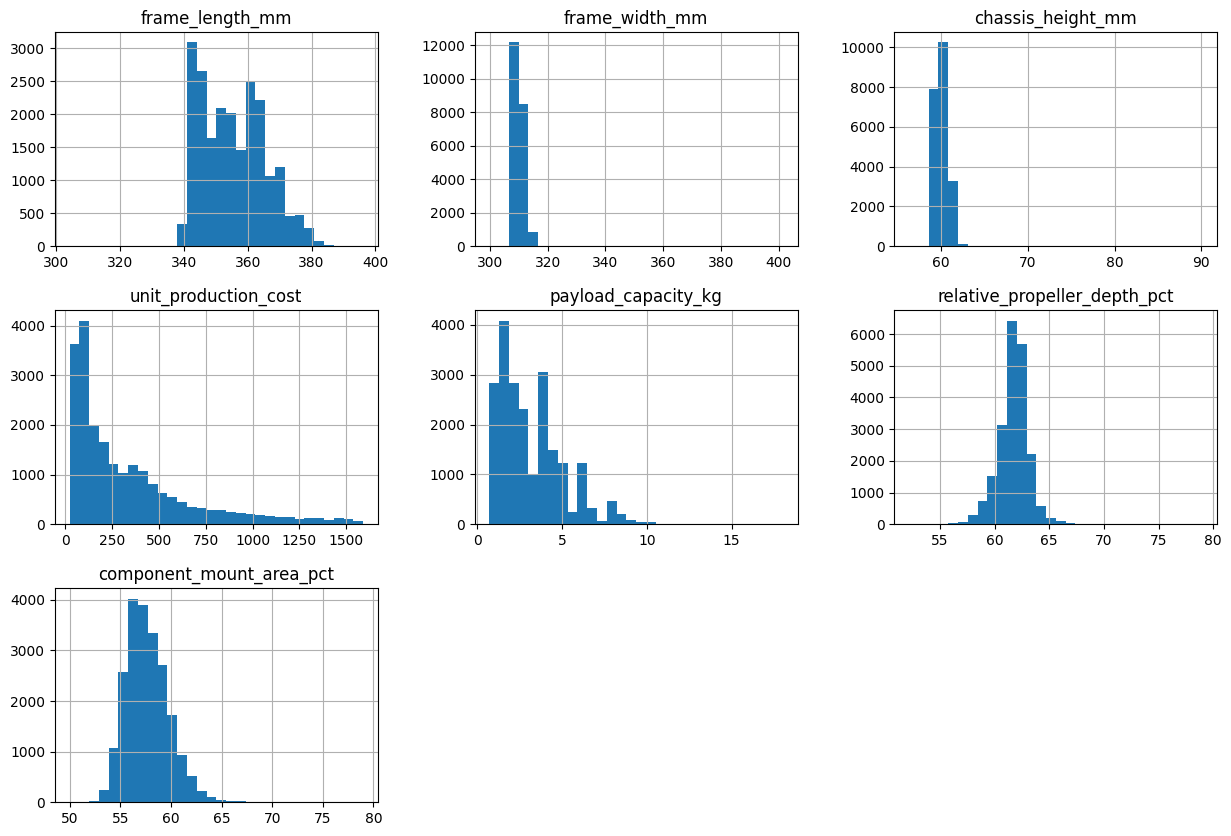

In [ ]:
import matplotlib.pyplot as plt

Drone_training.hist(bins=30, figsize=(15, 10))
plt.show()

In [ ]:
# Select only numerical columns
numerical_cols = Drone_training.select_dtypes(include=['float64']).columns

# Calculate skewness
skew_values = Drone_training[numerical_cols].skew().sort_values(ascending=False)
print(skew_values)

frame_width_mm                  4.691369
chassis_height_mm               3.113888
unit_production_cost            1.597391
payload_capacity_kg             1.132607
component_mount_area_pct        0.766148
frame_length_mm                 0.379785
relative_propeller_depth_pct    0.017006
dtype: float64


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cat_columns= Drone_training.select_dtypes(include=['str']).columns

levels=[
    ['Consumer-Entry','Consumer-Hobbyist','Consumer-Professional','High-End-Industrial-Sommercial','Aerospace-Mission-Critical'],
    ['Tier_7_Standard_Alloy','Tier_6_Enhanced_Polymer', 'Tier_5_Reinforced_Composite', 'Tier_4_Structural_Carbon',
      'Tier_3_Aviation_Steel', 'Tier_2_Titanium_Skeletal','Tier_1_Ultra_Light_Nano'],
    ['E', 'D2', 'D1', 'C2', 'C1','B2', 'B1','A1' ]
]

ord_encoder= OrdinalEncoder(categories =levels, handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)

copy_dt = Drone_training[cat_columns].copy()
copy_dt[['aerodynamic_rating_ord', 'material_purity_level_ord', 'lab_durability_rating_ord' ]] = ord_encoder.fit_transform(copy_dt[cat_columns])

new=['aerodynamic_rating_ord','aerodynamic_rating', 'material_purity_level','material_purity_level_ord', 'lab_durability_rating_ord', 'lab_durability_rating' ]

print(copy_dt[new].head())
print(cat_columns)


       aerodynamic_rating_ord             aerodynamic_rating  \
3658                     -1.0  High-End-Industral-Commercial   
257                       2.0          Consumer-Professional   
2202                      2.0          Consumer-Professional   
7375                      0.0                 Consumer-Entry   
10059                     4.0     Aerospace-Mission-Critical   

             material_purity_level  material_purity_level_ord  \
3658         Tier_7_Standard_Alloy                        0.0   
257        Tier_1_Ultra_Light_Nano                        6.0   
2202         Tier_3_Aviation_Steel                        4.0   
7375   Tier_5_Reinforced_Composite                        2.0   
10059      Tier_1_Ultra_Light_Nano                        6.0   

       lab_durability_rating_ord lab_durability_rating  
3658                         4.0                    C1  
257                          3.0                    C2  
2202                         1.0                    D

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer= SimpleImputer(strategy='median')

copy_dt1= Drone_training[numerical_cols].copy()


copy_dt1[numerical_cols]= num_imputer.fit_transform(copy_dt1[numerical_cols])

In [ ]:
print(
print(f"Missing values: {copy_dt1[numerical_cols].isna().sum()}"))

Missing values: frame_length_mm                 0
frame_width_mm                  0
chassis_height_mm               0
unit_production_cost            0
payload_capacity_kg             0
relative_propeller_depth_pct    0
component_mount_area_pct        0
dtype: int64
None


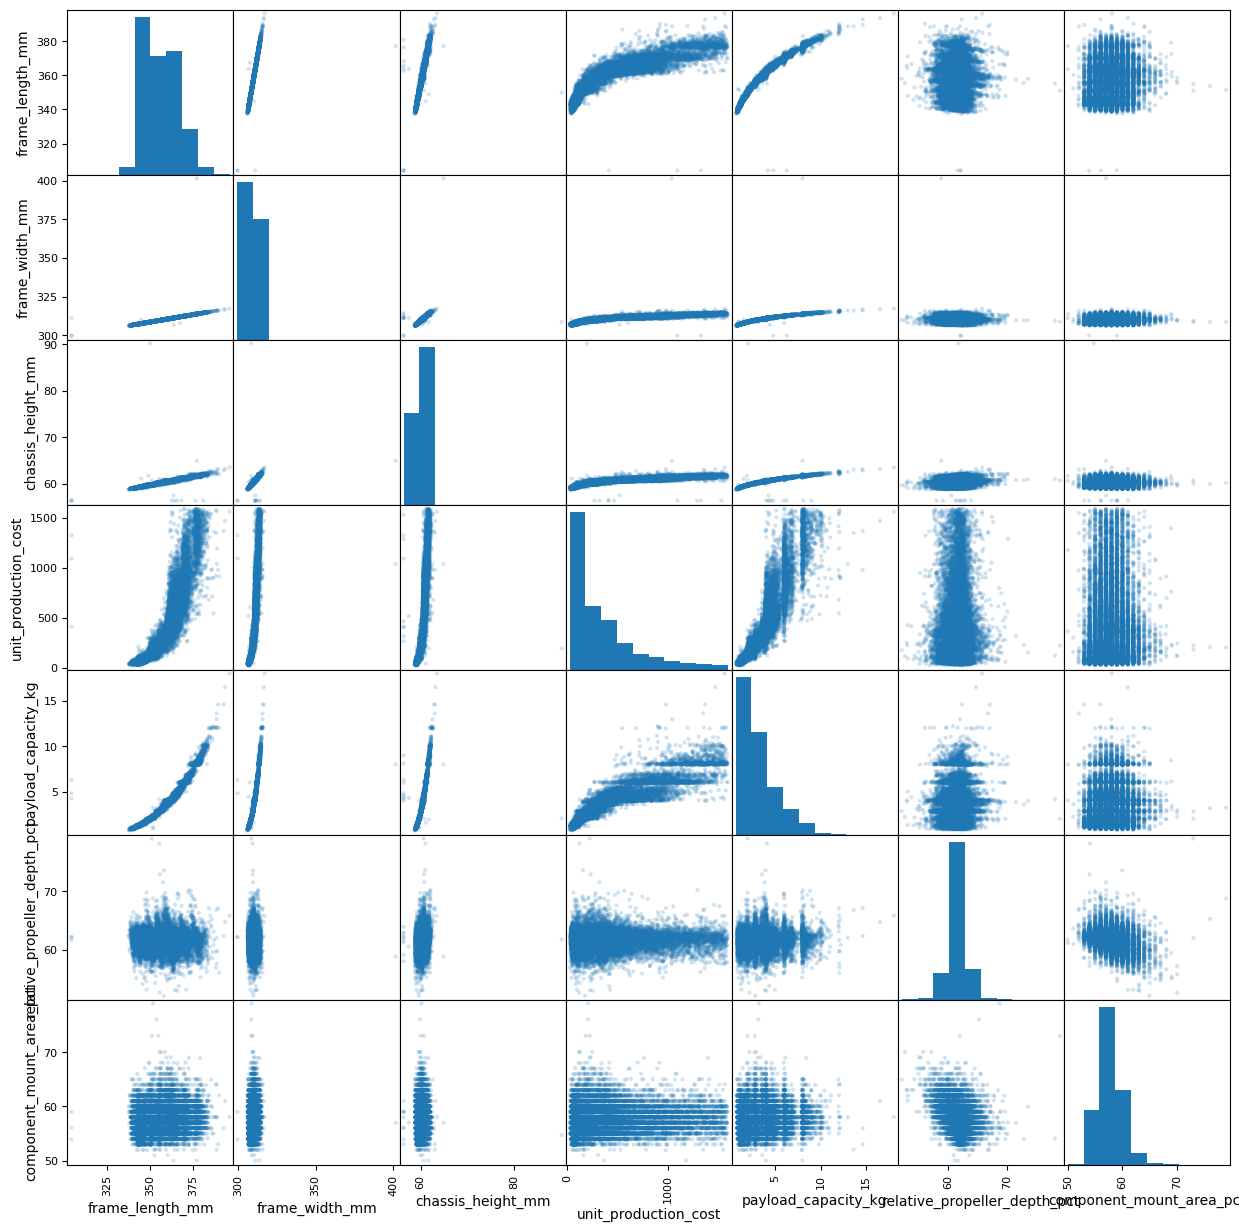

In [ ]:

from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Create the scatter plot matrix for all numeric columns in df
scatter_matrix(Drone_training, alpha=0.2, figsize=(15, 15))
plt.show()


#Pipeline Creation

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline


X = Drone_training.copy()
# y= Drone_training['unit_production_cost'].copy()


numerical_cols = X.select_dtypes(include=['float64']).columns
cat_columns= X.select_dtypes(include=['str']).columns

levels=[
    ['Consumer-Entry','Consumer-Hobbyist','Consumer-Professional','High-End-Industrial-Sommercial','Aerospace-Mission-Critical'],
    ['Tier_7_Standard_Alloy','Tier_6_Enhanced_Polymer', 'Tier_5_Reinforced_Composite', 'Tier_4_Structural_Carbon',
      'Tier_3_Aviation_Steel', 'Tier_2_Titanium_Skeletal','Tier_1_Ultra_Light_Nano'],
    ['E', 'D2', 'D1', 'C2', 'C1','B2', 'B1','A1' ]
]

#make the pipelines
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

cat_pipeline = make_pipeline(OrdinalEncoder(categories =levels, handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1))


preprocessing= ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, cat_columns)
])

pipeline= Pipeline([('preprocessor', preprocessing)])

pipeline.set_output(transform="pandas")
pipeline.fit(X)





,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [ ]:
# Set the output style to pandas
pipeline.set_output(transform="pandas")

# Transform and show the first 10 rows
X_processed = pipeline.transform(X)
X_processed.head(10)


,num__frame_length_mm,num__frame_width_mm,num__chassis_height_mm,num__unit_production_cost,num__payload_capacity_kg,num__relative_propeller_depth_pct,num__component_mount_area_pct,cat__aerodynamic_rating,cat__material_purity_level,cat__lab_durability_rating
3658,0.565821,0.500899,0.633968,0.056603,0.445000,0.732979,-0.221108,-1.0,0.0,4.0
257,-0.978967,-0.963875,-0.825826,-0.732263,-0.897882,1.188623,-1.106016,2.0,6.0,3.0
2202,-0.971955,-0.848724,-0.970310,-0.838408,-0.923379,0.064661,1.139057,2.0,4.0,1.0
7375,3.440245,3.111642,2.472373,1.718365,4.657332,-3.994601,2.067479,0.0,2.0,0.0
10059,-1.055391,-1.019780,-1.105856,-0.862339,-0.956317,-0.188750,-2.018835,4.0,6.0,2.0
11188,1.492033,1.359304,1.358865,2.552710,1.465925,-0.089875,0.264302,-1.0,4.0,3.0
11389,-0.916261,-0.873819,-0.878503,-0.687732,-0.822263,-0.063137,0.238407,2.0,3.0,6.0
21672,1.451093,1.302770,1.322198,1.195278,1.470789,-0.345206,1.585857,-1.0,1.0,2.0
24093,0.574283,0.528475,0.356296,-0.031900,0.263903,-1.592034,-0.250185,4.0,4.0,1.0
19854,-1.271872,-1.221827,-1.227116,-0.806527,-1.047830,0.031624,-0.703356,4.0,5.0,5.0


In [ ]:
Drone_training['unit_production_cost'].describe()

count    21576.000000
mean       341.117960
std        334.152931
min         23.153193
25%         90.922354
50%        213.436389
75%        461.537554
max       1589.851929
Name: unit_production_cost, dtype: float64

#Linear regression Model

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

X = Drone_training.drop(columns=['unit_production_cost']).copy()
y= Drone_training['unit_production_cost'].copy()


numerical_cols = X.select_dtypes(include=['float64']).columns
cat_columns= X.select_dtypes(include=['str']).columns

levels=[
    ['Consumer-Entry','Consumer-Hobbyist','Consumer-Professional','High-End-Industrial-Sommercial','Aerospace-Mission-Critical'],
    ['Tier_7_Standard_Alloy','Tier_6_Enhanced_Polymer', 'Tier_5_Reinforced_Composite', 'Tier_4_Structural_Carbon',
      'Tier_3_Aviation_Steel', 'Tier_2_Titanium_Skeletal','Tier_1_Ultra_Light_Nano'],
    ['E', 'D2', 'D1', 'C2', 'C1','B2', 'B1','A1' ]
]

#make the pipelines
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

cat_pipeline = make_pipeline(OrdinalEncoder(categories =levels, handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1))


preprocessing= ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, cat_columns)
])

pipeline1= Pipeline([
    ('preprocessor', preprocessing),
    ('model', LinearRegression())
    ])

pipeline1.fit(X,y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#Evaulation Metrics (RMSE)

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

rmse_scores=- cross_val_score(pipeline1, X,y, cv=4, scoring='neg_root_mean_squared_error')

print(f"The mean of the RMSE {rmse_scores.mean():.4f}")
print(f"RMSE Stability (Std Dev of CV): {rmse_scores.std():.2f}")

r2_scores=cross_val_score(pipeline1, X,y, cv=4, scoring='r2')
mae_scores=- cross_val_score(pipeline1, X,y, cv=4, scoring='neg_mean_absolute_error')

print(f"The mean of the r2 {r2_scores.mean():.4f}")
print(f"The mean of the MAE {mae_scores.mean():.4f}")

The mean of the RMSE 106.9098
RMSE Stability (Std Dev of CV): 2.46
The mean of the r2 0.8976
The mean of the MAE 70.0755


In [ ]:
X_test = Drone_test.drop(columns=['unit_production_cost']).copy()
y_test = Drone_test['unit_production_cost'].copy()
y_pred1=pipeline1.predict(X_test)
from sklearn.metrics import root_mean_squared_error,mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred1)
rmse=root_mean_squared_error(y_test, y_pred1)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2: {r2:.4f}")


Test RMSE: 106.9301
Test R2: 0.8996


#

#SVC Model using an RBF Kernel

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
# y_std = np.std(y)
# print(f"Standard Deviation of y: {y_std:.2f}")
# print(f"Your Cross-Val RMSE: 106.9")
from sklearn.svm import SVC

X = Drone_training.drop(columns=['unit_production_cost']).copy()
y= Drone_training['unit_production_cost'].copy()

y = (y>1000).astype(int)# is y greater than 1000



numerical_cols = X.select_dtypes(include=['float64']).columns
cat_columns= X.select_dtypes(include=['str']).columns

levels=[
    ['Consumer-Entry','Consumer-Hobbyist','Consumer-Professional','High-End-Industrial-Sommercial','Aerospace-Mission-Critical'],
    ['Tier_7_Standard_Alloy','Tier_6_Enhanced_Polymer', 'Tier_5_Reinforced_Composite', 'Tier_4_Structural_Carbon',
      'Tier_3_Aviation_Steel', 'Tier_2_Titanium_Skeletal','Tier_1_Ultra_Light_Nano'],
    ['E', 'D2', 'D1', 'C2', 'C1','B2', 'B1','A1' ]
]

#make the pipelines
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

cat_pipeline = make_pipeline(OrdinalEncoder(categories =levels, handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1))


preprocessing= ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, cat_columns)
])

custom_weights = {0: 1, 1: 2}
pipeline2= Pipeline([
    ('preprocessor', preprocessing),
    ('model', SVC(C=0.06, kernel='rbf' ,gamma=0.05 ,class_weight=custom_weights,random_state=42))
])

pipeline2.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#Evaluation Metrics (RMSE)

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
precision = cross_val_score(pipeline2, X,y, cv=4, scoring='precision')
print(f"The mean of the precision {precision.mean():.4f}")

recall=cross_val_score(pipeline2, X,y, cv=4, scoring='recall')
print(f"The mean of the recall {recall.mean():.4f}")

The mean of the precision 0.8178
The mean of the recall 0.9212


In [ ]:
f1_score =cross_val_score(pipeline2, X,y, cv=4, scoring='f1')
print(f"The mean of the f1-score {f1_score.mean():.4f}")

The mean of the f1-score 0.8664


# Model evaluation on SVC with RBF kernel (Confusion Matrix)

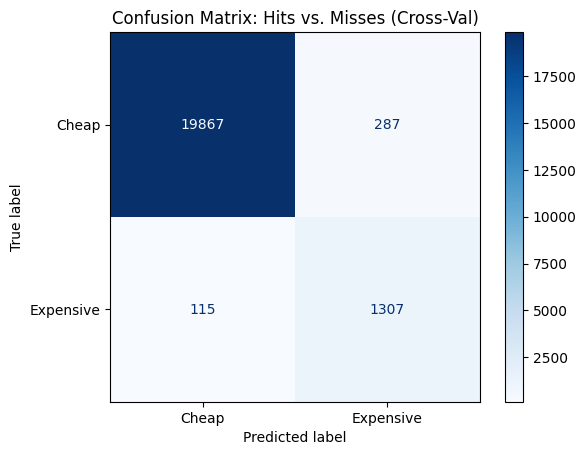

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_train_pred = cross_val_predict(pipeline2, X, y, cv=5)

cm = confusion_matrix(y, y_train_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cheap', 'Expensive'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Hits vs. Misses (Cross-Val)")
plt.show()

In [ ]:
X_test= Drone_test.drop(columns='unit_production_cost').copy()
y_test = Drone_test['unit_production_cost'].copy()
y_test = (y_test>1000).astype(int)

In [ ]:
y_pred = pipeline2.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

cm_test = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Set):")
print(cm_test)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5012
           1       0.83      0.93      0.88       382

    accuracy                           0.98      5394
   macro avg       0.91      0.96      0.93      5394
weighted avg       0.98      0.98      0.98      5394

Confusion Matrix (Test Set):
[[4940   72]
 [  26  356]]


In [ ]:
play= Drone_training['unit_production_cost'].copy()
play = (play>1000).astype(int)


Text(0.5, 0, 'Class')

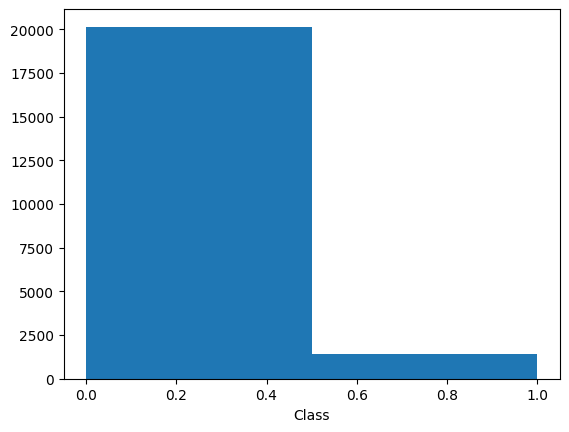

In [ ]:
import matplotlib.pyplot as plt
plt.hist(play, bins=2)
plt.xlabel('Class')

In [ ]:
play.value_counts()

unit_production_cost
0    20154
1     1422
Name: count, dtype: int64